In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fitting 3 folds for each of 18 candidates, totalling 54 fits

En iyi parametreler:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

GridSearch SVM Sonuçları:
              precision    recall  f1-score   support

       angry       0.84      0.85      0.85       115
        calm       0.83      0.85      0.84       115
     disgust       0.72      0.79      0.75       115
        fear       0.80      0.76      0.78       115
       happy       0.74      0.70      0.72       115
     neutral       0.71      0.69      0.70        58
         sad       0.68      0.70      0.69       115
    surprise       0.77      0.73      0.75       116

    accuracy                           0.77       864
   macro avg       0.76      0.76      0.76       864
weighted avg       0.77      0.77      0.76       864



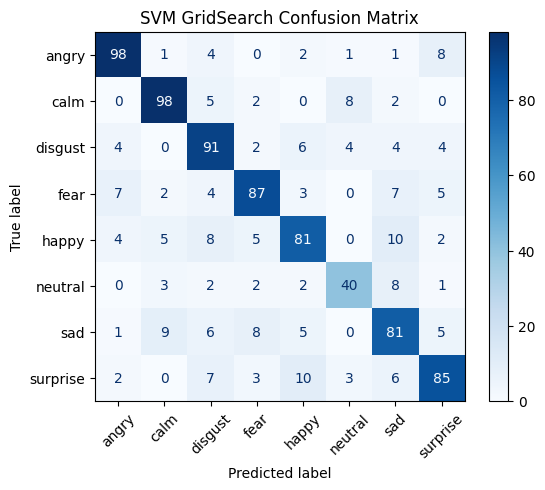


🔮 Tahmin edilen duygu: fear
🎯 Sınıf olasılıkları:
angry: 0.184
calm: 0.147
disgust: 0.098
fear: 0.243
happy: 0.246
neutral: 0.004
sad: 0.049
surprise: 0.029


In [2]:
# GEREKLİ KÜTÜPHANELER
import pandas as pd
import numpy as np
import librosa
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# DRIVE MOUNT (Colab için)
from google.colab import drive
drive.mount('/content/drive')

# CSV YÜKLE
df = pd.read_csv('/content/drive/MyDrive/features.csv')
# ÖRNEK: CSV dosyanın tam yolunu yaz

# ÖZELLİK ve ETİKET AYRIŞTIR
X = df.drop(columns=['labels']).values
y = df['labels'].apply(lambda x: x.split('_')[1] if '_' in x else x).values

# LABEL ENCODE
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# EĞİTİM / TEST BÖL
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# SVM + GRIDSEARCH
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))  # predict_proba için gerekli
])

param_grid = {
    'svm__C': [1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'poly']
}

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

# SONUÇLAR
y_pred_grid = grid.predict(X_test)
y_test_labels = le.inverse_transform(y_test)

print("\nEn iyi parametreler:")
print(grid.best_params_)
print("\nGridSearch SVM Sonuçları:")
print(classification_report(y_test_labels, le.inverse_transform(y_pred_grid)))

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("SVM GridSearch Confusion Matrix")
plt.show()

# MODEL ve ENCODER KAYDET
joblib.dump(grid.best_estimator_, '/content/drive/MyDrive/svm_best_model.pkl')
joblib.dump(le, '/content/drive/MyDrive/svm_label_encoder.pkl')

# ÖZELLİK ÇIKARIM FONKSİYONU
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=48000)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    return mfccs_mean

# TAHMİN FONKSİYONU
def predict_emotion(file_path):
    model = joblib.load('/content/drive/MyDrive/svm_best_model.pkl')
    le = joblib.load('/content/drive/MyDrive/svm_label_encoder.pkl')

    features = extract_features(file_path).reshape(1, -1)

    pred = model.predict(features)
    proba = model.predict_proba(features)

    print(f"\n🔮 Tahmin edilen duygu: {le.inverse_transform(pred)[0]}")
    print("🎯 Sınıf olasılıkları:")
    for label, p in zip(le.classes_, proba[0]):
        print(f"{label}: {p:.3f}")

# KENDİ SES DOSYANI TAHMİN ET
predict_emotion('/content/drive/MyDrive/recording-20250614-174033.wav')
# ÖRNEK: Ses dosyanın tam yolunu yaz


In [ ]:
predict_emotion('/content/drive/MyDrive/aa.wav')


🔮 Tahmin edilen duygu: happy
🎯 Sınıf olasılıkları:
angry: 0.104
calm: 0.019
disgust: 0.044
fear: 0.165
happy: 0.628
neutral: 0.002
sad: 0.027
surprise: 0.010


In [9]:
predict_emotion('/content/drive/MyDrive/angry.wav')


🔮 Tahmin edilen duygu: happy
🎯 Sınıf olasılıkları:
angry: 0.171
calm: 0.000
disgust: 0.007
fear: 0.000
happy: 0.821
neutral: 0.000
sad: 0.000
surprise: 0.001
